# 03. Evaluation

Training tells us whether the loss went down. Evaluation tells us whether the reconstructed MR volumes are actually useful.This notebook provides a step-by-step evaluation workflow for the super-resolution models trained in the previous tutorial.

We will load trained checkpoints for UNet, DDPM, and Flow Matching, run them on the same test split, save their predictions, and compare them from both quantitative and qualitative perspectives.

The main outputs are:
- PSNR, SSIM, and MAE for image quality comparison
- inference speed, reported as `samples/sec` and `ms/sample`
- 3D ground-truth-vs-prediction visualizations for qualitative inspection


## 1. Setup

We first import the evaluation utilities and locate the project root.

In [2]:
import os
from pathlib import Path
import time
import yaml
import torch
import pandas as pd
import pytorch_lightning as pl
from tqdm import tqdm
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics.regression import MeanAbsoluteError

from utils import (
    instantiate_from_config,
    get_module_from_config,
    prepare_src_slice_for_save,
    save_2d_nifti,
    stack_to_3d,
    visualize_gt_pred_from_3d_dir,
)

# If current directory is tutorial/, go back to project root; otherwise use current directory.
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "tutorial" else cwd
config_dir = project_root / "config"

print("project_root:", project_root)
print("config_dir:", config_dir)

project_root: E:\MRI_SR_Tutorial
config_dir: E:\MRI_SR_Tutorial\config


## 2. Load Config, Model, and Checkpoint

Evaluation should use the same settings that were used during training. The helper function below keeps the key steps explicit:

1. Read the YAML config file.
2. Build the DataModule and prepare the test split.
3. Instantiate the model class specified in the config.
4. Load `trainer.ckpt_dir/last.ckpt` using the same model parameters.

With this wrapper, switching between UNet, DDPM, and Flow Matching only requires changing the config file. The dataloader, checkpoint path, and model constructor remain tied to the experiment that produced the checkpoint.


In [3]:
def load_config(config_path: Path):
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def _resolve_root_relative(v: str, project_root: Path) -> str:
    p = Path(v)
    if p.is_absolute():
        return str(p.resolve())
    return str((project_root / p).resolve())


def resolve_ckpt_path(config: dict, project_root: Path) -> Path:
    ckpt_dir = (project_root / config["trainer"]["ckpt_dir"]).resolve()
    path = (ckpt_dir / "last.ckpt").resolve()
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")
    return path


def load_model_and_test_loader(config_path: Path, project_root: Path):
    config_path = Path(config_path).resolve()
    project_root = Path(project_root).resolve()
    config = load_config(config_path)

    # Resolve all root-relative paths from YAML into absolute paths.
    config["data"]["params"]["data_dir"] = _resolve_root_relative(config["data"]["params"]["data_dir"], project_root)
    config["trainer"]["ckpt_dir"] = _resolve_root_relative(config["trainer"]["ckpt_dir"], project_root)
    if "test_output_dir" in config:
        config["test_output_dir"] = _resolve_root_relative(config["test_output_dir"], project_root)
    pl.seed_everything(config["seed"], workers=True)

    dm = instantiate_from_config(
        model_name=config["data"]["target"],
        **config["data"]["params"],
    )
    dm.setup(stage="test")

    model_class = get_module_from_config(config["model"]["target"])
    resolved_ckpt = resolve_ckpt_path(config, project_root)
    model = model_class.load_from_checkpoint(resolved_ckpt, **config["model"]["params"])

    return config, model, dm.test_dataloader(), resolved_ckpt

## 3. Unified Evaluation Function: Metrics and Speed

Next, we define a common evaluation loop. All models should be evaluated with the same function so that the comparison is fair.

For each batch, the function generates a prediction, updates PSNR, SSIM, and MAE, and saves `src`, `dst`, and `dst_pred` as 2D NIfTI slices. After evaluation, these saved slices are stacked back into 3D volumes for visual inspection.


In [4]:
def evaluate_model(model, dataloader, device, num_inference_steps: int, result_dir: str):
    psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    mae = MeanAbsoluteError().to(device)

    os.makedirs(result_dir, exist_ok=True)
    result_dir_3d = result_dir + "_3d"

    model = model.to(device)
    model.eval()

    total_samples = 0
    t0 = time.perf_counter()

    scaler_dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
    with torch.inference_mode(), torch.autocast(device_type=device.type, dtype=scaler_dtype):
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            src = batch["src"].to(device)
            dst = batch["dst"].to(device)

            dst_pred = model.sample(src, num_inference_steps=num_inference_steps)

            psnr.update(dst_pred.float(), dst.float())
            ssim.update(dst_pred.float(), dst.float())
            mae.update(dst_pred.float(), dst.float())

            names = batch["name"]
            for b in range(src.shape[0]):
                base = os.path.join(result_dir, names[b])
                src_to_save = prepare_src_slice_for_save(src[b].detach().cpu())
                save_2d_nifti(src_to_save, base + "_src.nii.gz")
                save_2d_nifti(dst[b].detach().cpu(), base + "_dst.nii.gz")
                save_2d_nifti(dst_pred[b].detach().cpu(), base + "_dst_pred.nii.gz")
            total_samples += src.shape[0]

    elapsed = time.perf_counter() - t0
    samples_per_sec = total_samples / elapsed if elapsed > 0 else float("inf")
    ms_per_sample = (elapsed / total_samples * 1000.0) if total_samples > 0 else float("inf")

    stack_to_3d(result_dir, result_dir_3d, stack_axis=1)

    return {
        "PSNR": float(psnr.compute().item()),
        "SSIM": float(ssim.compute().item()),
        "MAE": float(mae.compute().item()),
        "elapsed_sec": float(elapsed),
        "num_samples": int(total_samples),
        "samples_per_sec": float(samples_per_sec),
        "ms_per_sample": float(ms_per_sample),
        "result_dir": result_dir,
        "result_dir_3d": result_dir_3d,
    }

## 4. Test the Three Models

This cell runs the actual benchmark. We evaluate the three trained models using the configs from the training tutorial:

- `config/unet_2p5d.yaml`
- `config/ddpm_2p5d.yaml`
- `config/fm_2p5d.yaml`

The number of inference steps is part of the comparison. UNet produces a prediction in a single forward pass, while DDPM and Flow Matching use iterative sampling. More sampling steps may improve generation quality, but they also increase inference time.

To evaluate another experiment, add a new entry to `model_entries` with a model name, a config path, and the number of sampling steps. The rest of the loop can remain unchanged.

Depending on your GPU and the number of test cases, this cell may take 10 mins to finish.

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_entries = [
    {"name": "UNet", "config": config_dir / "unet_2p5d.yaml", "num_inference_steps": 1},
    {"name": "DDPM", "config": config_dir / "ddpm_2p5d.yaml", "num_inference_steps": 100},
    {"name": "FlowMatching", "config": config_dir / "fm_2p5d.yaml", "num_inference_steps": 24},
]

results = []
for entry in model_entries:
    print(f"\n[RUN] {entry['name']} | config={entry['config']}")
    cfg, model, test_loader, ckpt = load_model_and_test_loader(entry["config"], project_root)
    print(f"[CKPT] {ckpt}")

    result_dir = cfg["test_output_dir"]

    metrics = evaluate_model(
        model=model,
        dataloader=test_loader,
        device=device,
        num_inference_steps=entry["num_inference_steps"],
        result_dir=result_dir,
    )
    print(f"[SAVE 2D] {result_dir}")
    print(f"[SAVE 3D] {metrics['result_dir_3d']}")
    metrics["model"] = entry["name"]
    metrics["config"] = str(entry["config"])
    metrics["ckpt"] = str(ckpt)
    results.append(metrics)

device:

Seed set to 24


 cuda:0

[RUN] UNet | config=E:\MRI_SR_Tutorial\config\unet_2p5d.yaml
[CKPT] E:\MRI_SR_Tutorial\checkpoints\UNet_2p5d\last.ckpt


Seed set to 24                                               


[SAVE 2D] E:\MRI_SR_Tutorial\results\UNet_2p5d
[SAVE 3D] E:\MRI_SR_Tutorial\results\UNet_2p5d_3d

[RUN] DDPM | config=E:\MRI_SR_Tutorial\config\ddpm_2p5d.yaml
[CKPT] E:\MRI_SR_Tutorial\checkpoints\DDPM_2p5d\last.ckpt


Seed set to 24                                               


[SAVE 2D] E:\MRI_SR_Tutorial\results\DDPM_2p5d
[SAVE 3D] E:\MRI_SR_Tutorial\results\DDPM_2p5d_3d

[RUN] FlowMatching | config=E:\MRI_SR_Tutorial\config\fm_2p5d.yaml
[CKPT] E:\MRI_SR_Tutorial\checkpoints\FlowMatching_2p5d\last.ckpt


[SAVE 2D] E:\MRI_SR_Tutorial\results\FlowMatching_2p5d
[SAVE 3D] E:\MRI_SR_Tutorial\results\FlowMatching_2p5d_3d


## 5. Compare PSNR, SSIM, MAE, and Inference Speed

The table below summarizes both reconstruction quality and inference cost.

How to read the metrics:
- Higher PSNR and SSIM are better.
- Lower MAE is better.
- Higher `samples_per_sec`, or lower `ms_per_sample`, means faster inference.

PSNR, SSIM, and MAE provide a useful quantitative summary on image quality, but they do not capture every aspect of image quality. A model with good metrics can still produce overly smooth images or local artifacts, so visual inspection is still necessary.

In [6]:
df = pd.DataFrame(results)
show_cols = [
    "model", "PSNR", "SSIM", "MAE", "samples_per_sec", "ms_per_sample", "elapsed_sec", "num_samples"
]
df_show = df[show_cols].copy()
df_show = df_show.sort_values(by="PSNR", ascending=False).reset_index(drop=True)
df_show

,model,PSNR,SSIM,MAE,samples_per_sec,ms_per_sample,elapsed_sec,num_samples
0,UNet,35.640942,0.957416,0.007428,17.086780,58.524779,78.657303,1344
1,FlowMatching,33.508633,0.900923,0.010722,10.404404,96.113142,129.176063,1344
2,DDPM,31.661713,0.835899,0.014198,3.598276,277.910894,373.512241,1344


In [7]:
out_csv = (project_root / "results" / "evaluation_summary.csv").resolve()
out_csv.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_csv, index=False, encoding="utf-8-sig")
print("saved:", out_csv)
print("encoding: utf-8-sig")

saved: E:\MRI_SR_Tutorial\results\evaluation_summary.csv
encoding: utf-8-sig


## 6. Three-View Visualization

The final step is to inspect the reconstructed 3D volumes. Global metrics average over many voxels, so they can hide local problems such as blurred tissue boundaries, broken anatomical continuity, or structured artifacts.

The prediction folders were created by the evaluation loop:

- `results/UNet_2p5d_3d`
- `results/DDPM_2p5d_3d`
- `results/FlowMatching_2p5d_3d`

For each selected case, we display the LR/source image (`src_3d`), the HR ground truth (`dst_3d`), and the SR prediction (`dst_pred_3d`) using sagittal, coronal, and axial center slices.



[UNet] E:\MRI_SR_Tutorial\results\UNet_2p5d_3d


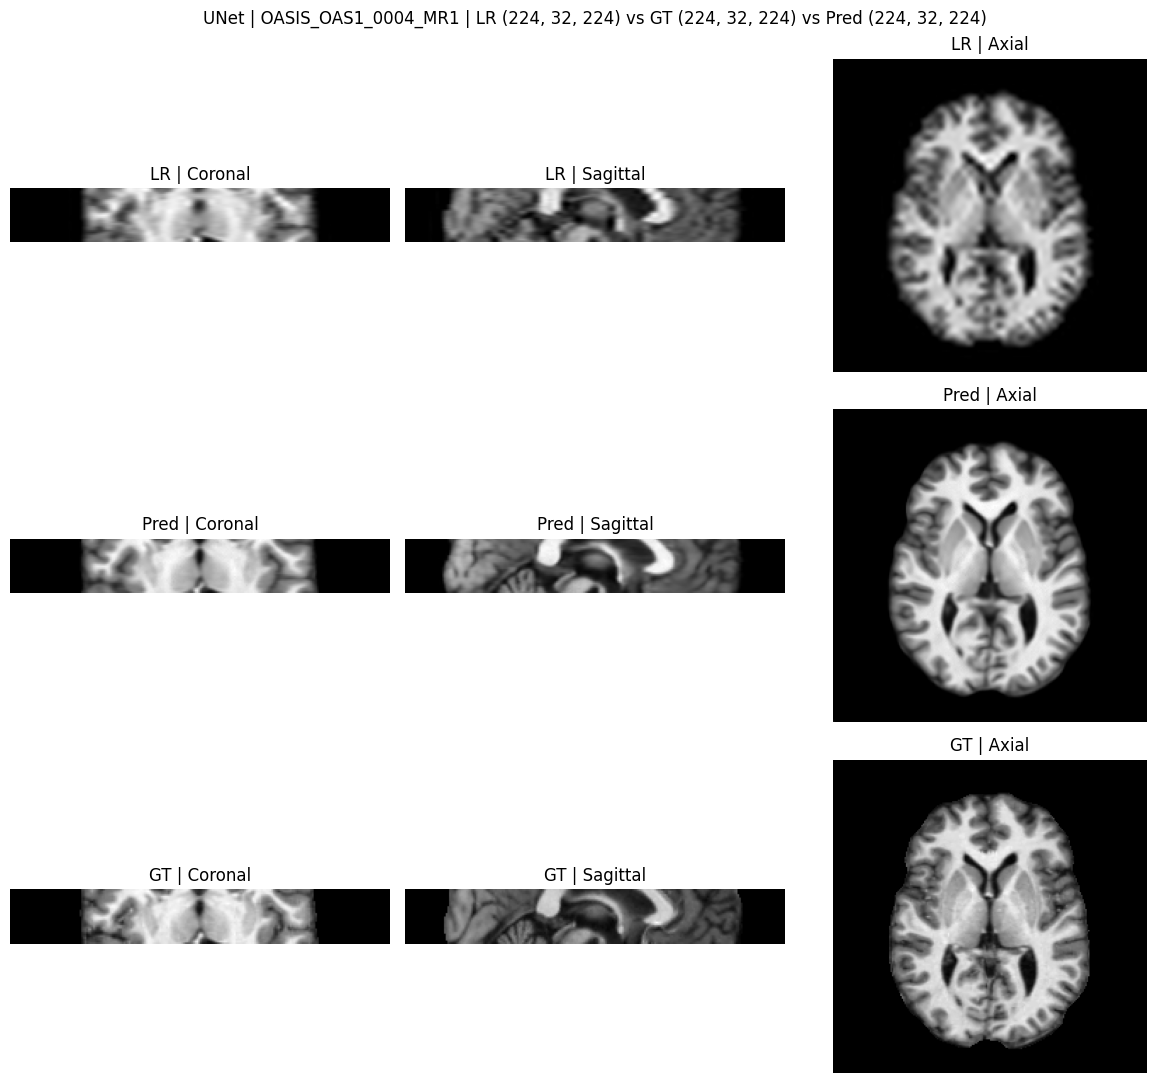


[DDPM] E:\MRI_SR_Tutorial\results\DDPM_2p5d_3d


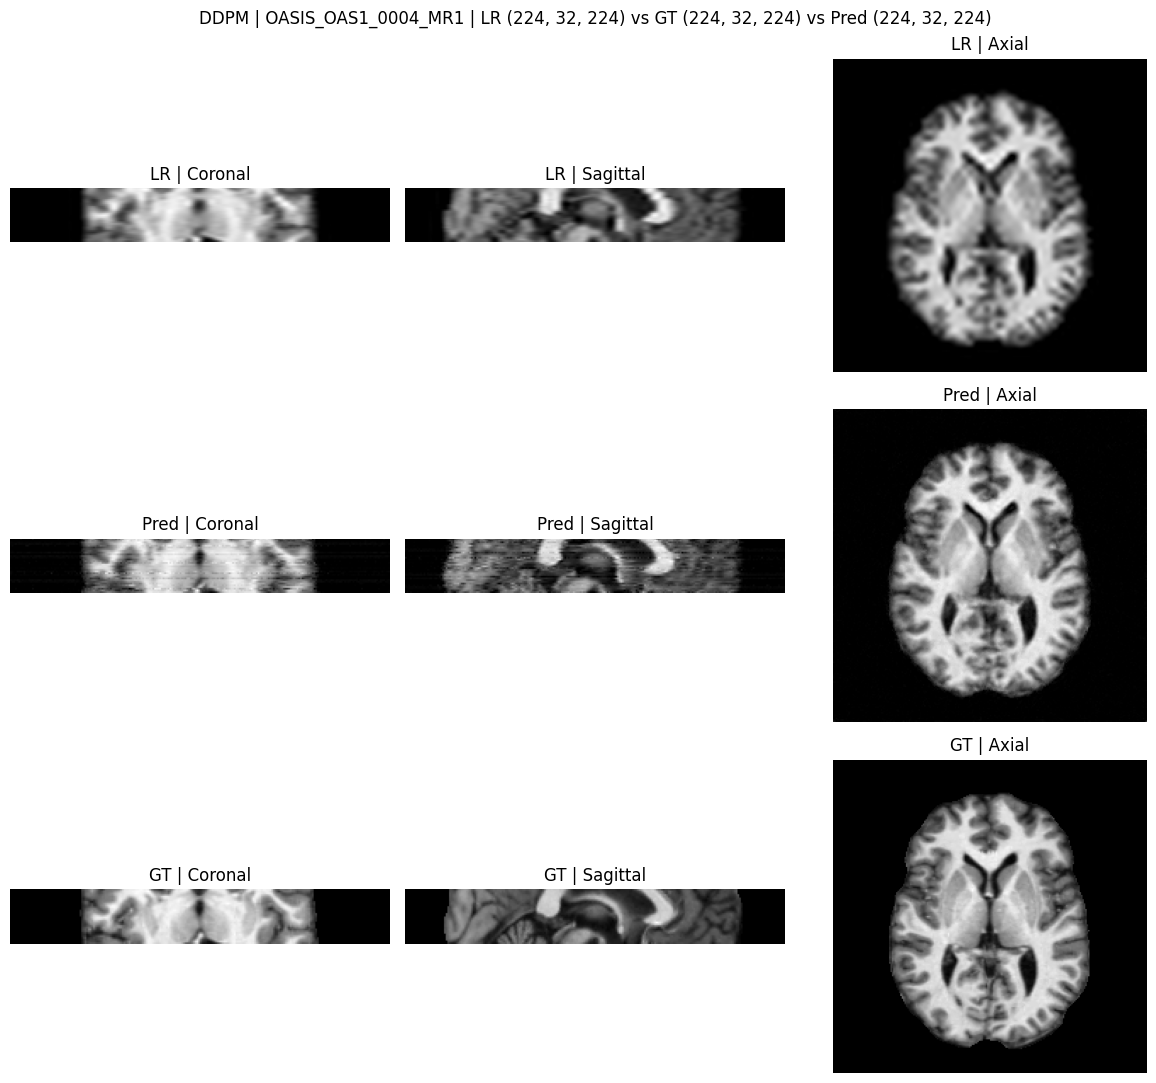


[FlowMatching] E:\MRI_SR_Tutorial\results\FlowMatching_2p5d_3d


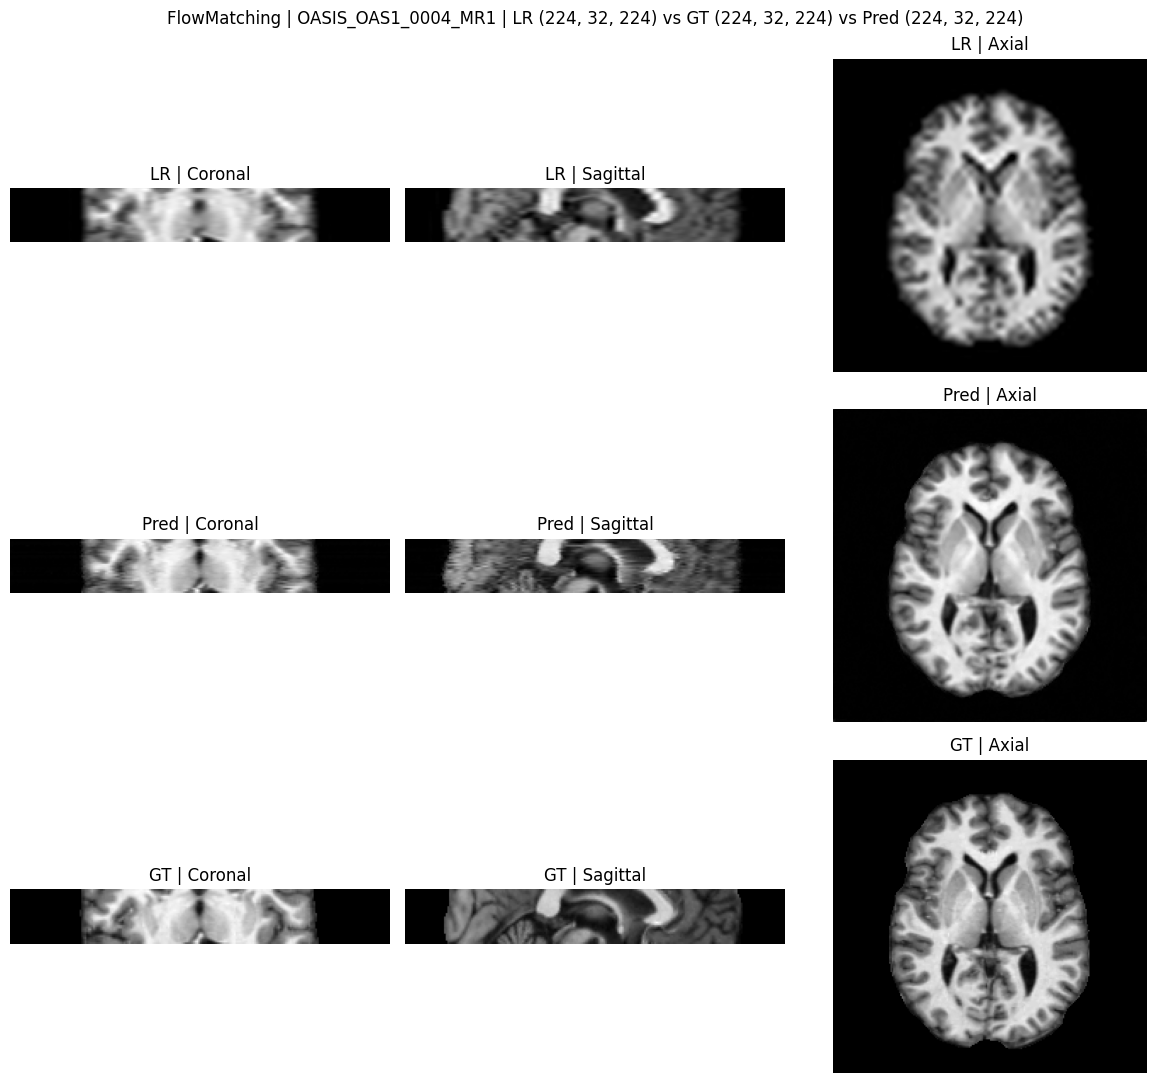

In [8]:
result_3d_dirs = {
    "UNet": project_root / "results" / "UNet_2p5d_3d",
    "DDPM": project_root / "results" / "DDPM_2p5d_3d",
    "FlowMatching": project_root / "results" / "FlowMatching_2p5d_3d",
}

max_cases_per_model = 1
for model_name, d in result_3d_dirs.items():
    visualize_gt_pred_from_3d_dir(d, model_name=model_name, max_cases=max_cases_per_model)